# TradingAgents with Databricks - Clean Output

This notebook runs TradingAgents analysis and generates:
- Clean markdown reports (no debug logs)
- Price history charts
- Organized analysis sections

Output saved to: `analysis_results/{symbol}/{symbol}_{timestamp}.md`

In [1]:
import os
import sys
from datetime import datetime, timedelta
from pathlib import Path
from dotenv import load_dotenv
from tradingagents.graph.trading_graph import TradingAgentsGraph
from tradingagents.default_config import DEFAULT_CONFIG
import io
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

%matplotlib inline

In [2]:
# Load environment variables from .env file
load_dotenv()

# Check if Databricks credentials are set
if not os.getenv("DATABRICKS_TOKEN"):
    print("ERROR: DATABRICKS_TOKEN environment variable is not set")
else:
    print("✓ DATABRICKS_TOKEN is set")

if not os.getenv("DATABRICKS_BASE_URL"):
    print("ERROR: DATABRICKS_BASE_URL environment variable is not set")
else:
    print("✓ DATABRICKS_BASE_URL is set")

✓ DATABRICKS_TOKEN is set
✓ DATABRICKS_BASE_URL is set


In [3]:
# Create a custom config
config = DEFAULT_CONFIG.copy()
config["llm_provider"] = "databricks"
config["deep_think_llm"] = "databricks-claude-sonnet-4-5"  # Specify your Databricks model name here
config["quick_think_llm"] = "llama_v3_3_70b_instruct_pro" # And here

# Fix the base URL to include /serving-endpoints
if config["databricks_base_url"] and not config["databricks_base_url"].endswith("/serving-endpoints"):
    config["databricks_base_url"] = config["databricks_base_url"].rstrip("/") + "/serving-endpoints"

print("Configuration:")
print(f"  LLM Provider: {config['llm_provider']}")
print(f"  Deep Think Model: {config['deep_think_llm']}")
print(f"  Quick Think Model: {config['quick_think_llm']}")
print(f"  Databricks Base URL: {config['databricks_base_url']}")
print(f"  Databricks Token: {'*' * 20 if config['databricks_token'] else 'NOT SET'}")

Configuration:
  LLM Provider: databricks
  Deep Think Model: databricks-claude-sonnet-4-5
  Quick Think Model: llama_v3_3_70b_instruct_pro
  Databricks Base URL: https://adb-8333330282859393.13.azuredatabricks.net/serving-endpoints
  Databricks Token: ********************


In [4]:
# Initialize TradingAgentsGraph with debug=False for clean output
print("Initializing TradingAgentsGraph...")
ta = TradingAgentsGraph(debug=False, config=config)  # debug=False = no verbose logs
print("✓ Initialization successful!")

Initializing TradingAgentsGraph...
✓ Initialization successful!


In [5]:
# Helper function to create clean reports
def analyze_and_save(symbol, trade_date):
    """
    Run analysis and save clean markdown report with price chart.
    
    Args:
        symbol: Stock ticker (e.g., 'AAPL', 'MSFT')
        trade_date: Date string in format 'YYYY-MM-DD'
    
    Returns:
        tuple: (final_state, decision, output_file, chart_file)
    """
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Create output directory
    output_dir = Path("analysis_results") / symbol
    output_dir.mkdir(parents=True, exist_ok=True)
    output_file = output_dir / f"{symbol}_{timestamp}.md"
    chart_file = output_dir / f"{symbol}_{timestamp}_chart.png"
    
    print(f"\n{'='*80}")
    print(f"Analyzing {symbol} for {trade_date}")
    print(f"{'='*80}\n")
    
    # Run analysis (suppress debug output)
    old_stdout = sys.stdout
    sys.stdout = io.StringIO()  # Suppress verbose output
    
    try:
        final_state, decision = ta.propagate(symbol, trade_date)
    finally:
        sys.stdout = old_stdout  # Restore stdout
    
    print("✓ Analysis complete!\n")
    
    # Extract reports from final state
    market_report = final_state.get("market_report", "No market report available")
    fundamentals_report = final_state.get("fundamentals_report", "No fundamentals report available")
    news_report = final_state.get("news_report", "No news report available")
    sentiment_report = final_state.get("sentiment_report", "No sentiment report available")
    final_decision = final_state.get("final_trade_decision", decision)
    
    # Create price chart
    print("Creating price chart...")
    chart_created = False
    try:
        # Get 6 months of data
        end_date = datetime.strptime(trade_date, "%Y-%m-%d")
        start_date = end_date - timedelta(days=180)
        
        ticker = yf.Ticker(symbol)
        df = ticker.history(start=start_date.strftime("%Y-%m-%d"), end=trade_date)
        
        if not df.empty:
            fig, ax = plt.subplots(figsize=(12, 6))
            ax.plot(df.index, df['Close'], linewidth=2, color='#2E86AB')
            ax.fill_between(df.index, df['Close'], alpha=0.3, color='#2E86AB')
            
            ax.set_title(f'{symbol} Stock Price - Last 6 Months', fontsize=16, fontweight='bold')
            ax.set_xlabel('Date', fontsize=12)
            ax.set_ylabel('Price ($)', fontsize=12)
            ax.grid(True, alpha=0.3)
            
            # Add current price annotation
            current_price = df['Close'].iloc[-1]
            ax.annotate(f'${current_price:.2f}',
                       xy=(df.index[-1], current_price),
                       xytext=(10, 10), textcoords='offset points',
                       bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7),
                       fontsize=11, fontweight='bold')
            
            plt.tight_layout()
            plt.savefig(chart_file, dpi=150, bbox_inches='tight')
            plt.show()
            print(f"✓ Chart saved: {chart_file}\n")
            chart_created = True
        else:
            print("⚠ Could not fetch price data for chart\n")
    except Exception as e:
        print(f"⚠ Chart creation failed: {e}\n")
    
    # Write clean markdown report
    print("Writing markdown report...")
    with open(output_file, 'w') as f:
        f.write(f"# Trading Analysis Report\n\n")
        f.write(f"**Symbol:** {symbol}\n")
        f.write(f"**Trade Date:** {trade_date}\n")
        f.write(f"**Analysis Date:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"**LLM Provider:** {config['llm_provider']}\n")
        f.write(f"**Models:** Deep Think: {config['deep_think_llm']}, Quick Think: {config['quick_think_llm']}\n\n")
        
        if chart_created:
            f.write(f"## Price Chart\n\n")
            f.write(f"![{symbol} Price Chart](./{chart_file.name})\n\n")
        
        f.write(f"---\n\n")
        
        f.write(f"## Market Analysis\n\n")
        f.write(market_report)
        f.write(f"\n\n---\n\n")
        
        f.write(f"## Fundamental Analysis\n\n")
        f.write(fundamentals_report)
        f.write(f"\n\n---\n\n")
        
        f.write(f"## News Analysis\n\n")
        f.write(news_report)
        f.write(f"\n\n---\n\n")
        
        f.write(f"## Sentiment Analysis\n\n")
        f.write(sentiment_report)
        f.write(f"\n\n---\n\n")
        
        f.write(f"## Final Trading Decision\n\n")
        f.write(f"**{final_decision}**\n\n")
    
    print(f"✓ Report saved: {output_file}\n")
    
    # Display decision
    print("="*80)
    print("FINAL DECISION")
    print("="*80)
    print(final_decision)
    print("="*80)
    
    return final_state, decision, output_file, chart_file

## Run Single Stock Analysis


Analyzing NVDA for 2025-10-28

✓ Analysis complete!

Creating price chart...


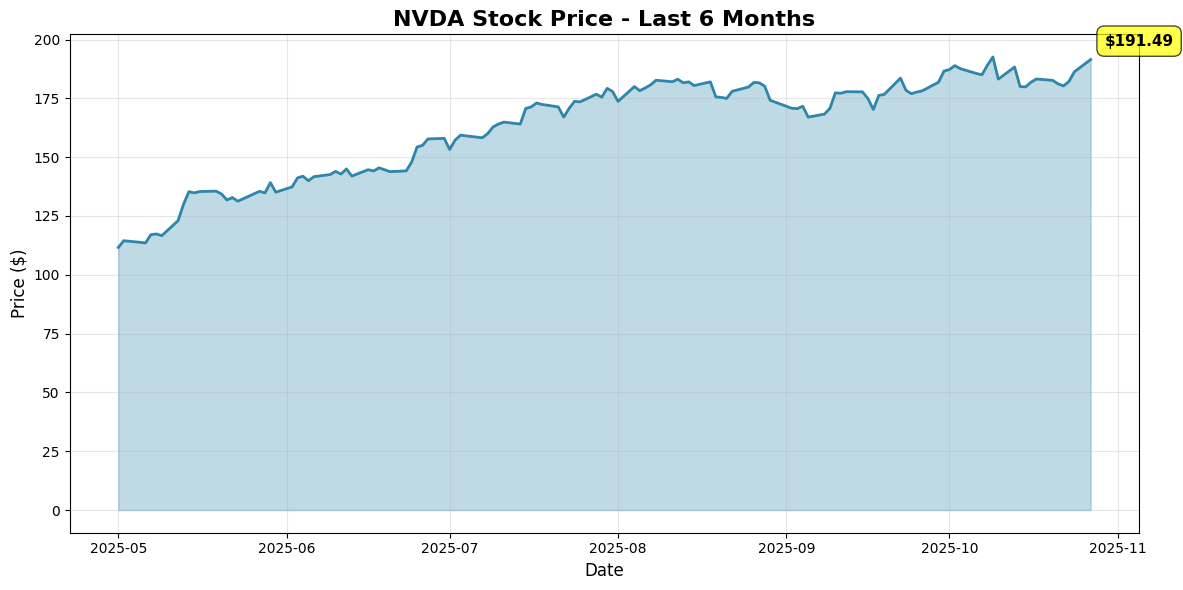

✓ Chart saved: analysis_results/NVDA/NVDA_20251028_131212_chart.png

Writing markdown report...
✓ Report saved: analysis_results/NVDA/NVDA_20251028_131212.md

FINAL DECISION
# RISK MANAGEMENT DECISION: NVIDIA CORPORATION

## FINAL RECOMMENDATION: **SELL** (Reduce Position/Take Profits)

After carefully evaluating all three analysts' perspectives and examining the specific market conditions, I'm making a decisive call to **SELL** or significantly reduce NVIDIA exposure at current levels. This is not a weak compromise—it's a conviction call based on risk-adjusted return analysis.

## CRITICAL ANALYSIS OF THE DEBATE

### Why the Risky Analyst is Wrong

The Risky Analyst's argument contains a fundamental flaw: **confusing business quality with investment timing**. Their key quote reveals the problem:

> "By waiting for such a significant pullback, we may miss out on potential upside in the short term."

This is classic FOMO (Fear of Missing Out) investing—the exact emotional trap that dest

In [6]:
# Analyze a single stock
symbol = "NVDA"
trade_date = datetime.today().strftime('%Y-%m-%d')

final_state, decision, output_file, chart_file = analyze_and_save(symbol, trade_date)

print(f"\nFiles created:")
print(f"  Report: {output_file}")
print(f"  Chart:  {chart_file}")

## Run Multiple Stocks Analysis


Analyzing AAPL for 2025-10-28

✓ Analysis complete!

Creating price chart...


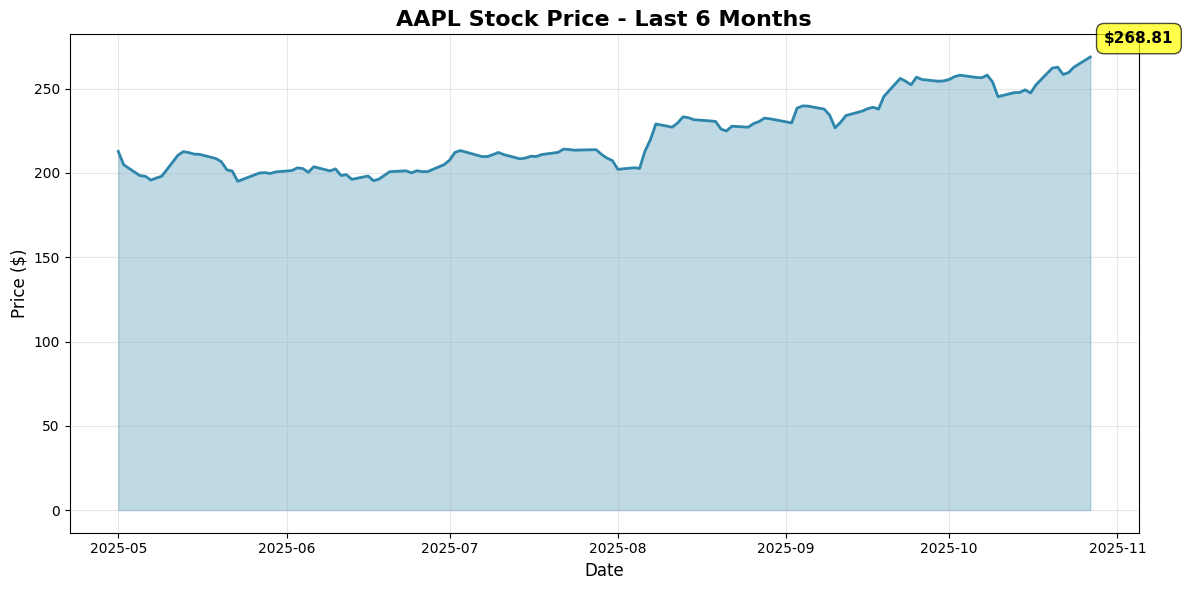

✓ Chart saved: analysis_results/AAPL/AAPL_20251028_131511_chart.png

Writing markdown report...
✓ Report saved: analysis_results/AAPL/AAPL_20251028_131511.md

FINAL DECISION
# RISK MANAGEMENT DECISION: APPLE INC. (AAPL)

## FINAL RECOMMENDATION: **HOLD** (Strongly Justified with Tactical Adjustments)

---

## EXECUTIVE SUMMARY

After carefully evaluating all three analysts' perspectives, I am issuing a **HOLD** recommendation with specific tactical adjustments. This is not a default position, but a strategically justified stance based on the tension between Apple's fundamental strength and its stretched valuation in an increasingly competitive environment.

**Key Decision Drivers:**
- Apple's business quality remains exceptional, but valuation leaves little margin for error
- Technical momentum is positive but showing overbought conditions (RSI concern)
- Competitive and innovation risks are material and underappreciated by the Risky Analyst
- The risk-reward profile at current prices 

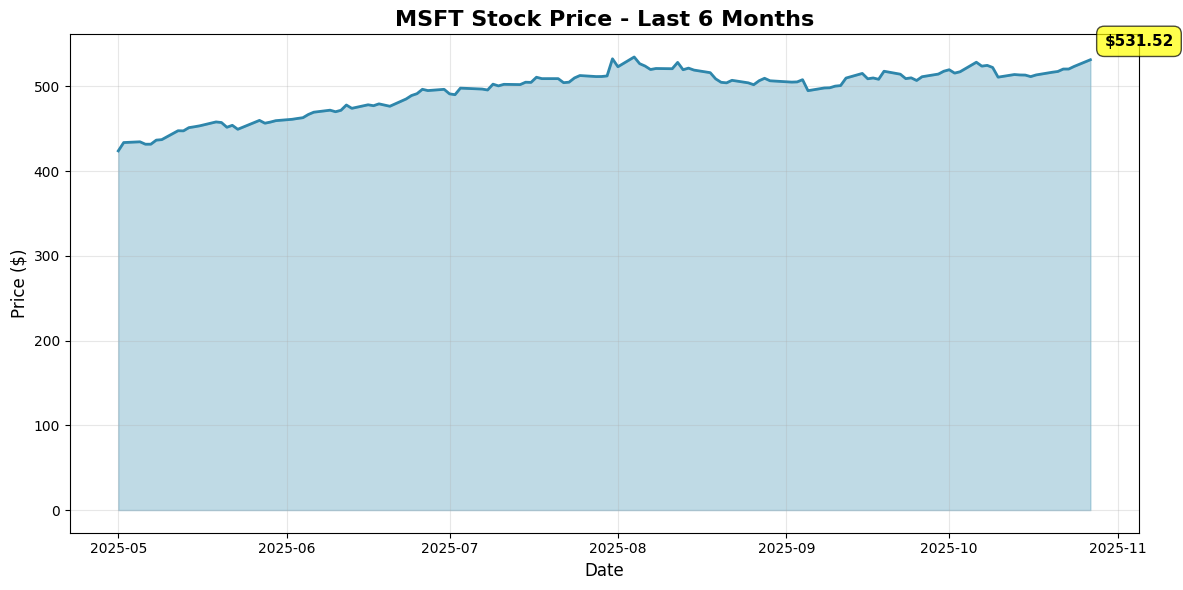

✓ Chart saved: analysis_results/MSFT/MSFT_20251028_132012_chart.png

Writing markdown report...
✓ Report saved: analysis_results/MSFT/MSFT_20251028_132012.md

FINAL DECISION
# Risk Management Decision: Microsoft (MSFT)

## Summary of Key Arguments

**Risky Analyst's Position:**
- MACD of 2.94 signals strong bullish momentum
- RSI at 66.58 shows room for growth without being overbought
- Social media sentiment score of 0.215164 indicates market optimism
- Strong fundamentals with increasing revenue and profitability
- Strategic OpenAI partnership positions MSFT as AI leader
- Quote: *"The potential benefits far outweigh the costs... those who are willing to take calculated risks are often the ones who reap the greatest rewards"*

**Safe Analyst's Position:**
- RSI at 66.58 is neutral, not a clear buy signal
- Significant AI adoption risks - market may not grow as expected
- Revenue growth has been slowing in recent years
- Increasing competition in AI market
- Global economic uncertaint

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: NNDA"}}}
$NNDA: possibly delisted; no timezone found
Getting Global News on 2025-10-28:   0%|          | 0/8 [00:00<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
# Analyze multiple stocks
symbols = ["AAPL", "MSFT", "NVDA", "ADBE", "TSLA"]
trade_date = datetime.today().strftime('%Y-%m-%d')

results = {}
for symbol in symbols:
    final_state, decision, output_file, chart_file = analyze_and_save(symbol, trade_date)
    results[symbol] = {
        'decision': decision,
        'output_file': output_file,
        'chart_file': chart_file
    }

# Summary
print("\n" + "="*80)
print("SUMMARY OF ALL ANALYSES")
print("="*80)
for symbol, data in results.items():
    print(f"\n{symbol}: {data['decision']}")
    print(f"  Report: {data['output_file']}")